In [1]:
import multiprocessing

from copy import deepcopy

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pickle
import seaborn as sns
import torch

import Figure_6B_utils as fig6b_utils

from Figure_6B_utils import (
    generalization_simple_complex_job,
    aggregate_codex_figure_5_generalization_results,
    build_codex_figure_5_experiment_params,
    measure_sleep_a_awake_generalization_job,
    measure_load_2_ctx_episode_selectivity_job,
    measure_sleep_a_replay_episode_clustering_job,
    plot_codex_figure_5,
    train_phase_split_networks,
)
from src.network_parameters import network_parameters
from src.utils.general import get_signal_to_noise_ratio


blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'

In [2]:
shared_num_seeds = 1
shared_seeds = list(range(shared_num_seeds))
shared_noise_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


network = torch.load("checkpoints/network_3_B.pt", weights_only=False)
shared_snr_levels = [
    get_signal_to_noise_ratio(level, network, region="mtl_sensory")
    for level in shared_noise_levels
]


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


## 6d. Unified CTX Generalization: Simple and Complex Concepts


In [3]:
import os
import torch

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_DYNAMIC"] = "FALSE"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
try:
    multiprocessing.set_start_method("fork")
except RuntimeError:
    pass

In [4]:
unified_input_params = {
    "num_days": 600,
    "day_length": 80,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 4,
}

unified_latent_specs = {
    "num": 2,
    "total_sizes": [50, 50],
    "act_sizes": [10, 10],
    "dims": [5, 5],
    "prob_list": [0.5 / 5 if i == j else 0.5 / 20 for i in range(5) for j in range(5)],
}

unified_num_cpu = 12
unified_job_print_rate = 50
unified_verbose_jobs = True
unified_seeds = shared_seeds
unified_noise_levels = shared_noise_levels
unified_network_modes = ["semantics_present", "semantics_absent", "semantics_random"]

unified_phase_A = 200
unified_phase_B = 400
unified_simple_train_days = 800
unified_simple_eval_days = 100
unified_complex_train_days = 400
unified_complex_eval_days = 100

unified_net_params = deepcopy(network_parameters)

unified_example_seed = unified_seeds[0]

unified_pretrain_num_swaps = 4
unified_record = False

In [5]:
generalization_simple_complex_experiment_params = [
    (
        network_mode,
        deepcopy(unified_net_params),
        deepcopy(unified_input_params),
        deepcopy(unified_latent_specs),
        int(num_swaps),
        int(seed),
        int(unified_pretrain_num_swaps),
        unified_phase_A,
        unified_phase_B,
        unified_simple_train_days,
        unified_simple_eval_days,
        unified_complex_train_days,
        unified_complex_eval_days,
        unified_job_print_rate,
        bool(unified_verbose_jobs),
        bool(int(seed) == int(unified_example_seed)),
        bool(unified_record),
    )
    for seed in unified_seeds
    for network_mode in unified_network_modes
    for num_swaps in unified_noise_levels
]


In [6]:
with multiprocessing.Pool(processes=unified_num_cpu) as pool:
    generalization_simple_complex_job_results = pool.starmap(
        generalization_simple_complex_job,
        generalization_simple_complex_experiment_params,
    )

[pid=44724] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=4[pid=44721] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=1[pid=44725] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=5
[pid=44722] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=2[pid=44726] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=6[pid=44730] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=10

[pid=44723] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=3[pid=44729] START generalization_simple_complex mode=semantics_present seed=0 num_swaps=9




[pid=44724] generalization_simple_complex mode=semantics_present seed=0 num_swaps=4 checkpoint=simple_train_prephaseB_start[pid=44725] generalization_simple_complex mode=semantics_present seed=0 num_swaps=5 checkpoint=simple_train_prephaseB_start[pid=44721] generalization_simple

In [7]:
def aggregate_generalization_simple_complex_results(job_results, noise_levels=None, seeds=None, network_modes=None):
    if len(job_results) == 0:
        raise ValueError("job_results cannot be empty.")

    if noise_levels is None:
        noise_levels = sorted({int(job["num_swaps"]) for job in job_results})
    else:
        noise_levels = [int(level) for level in noise_levels]

    if seeds is None:
        seeds = sorted({int(job["seed"]) for job in job_results if job["seed"] is not None})
    else:
        seeds = [int(seed) for seed in seeds]

    if network_modes is None:
        network_modes = sorted({job["network_mode"] for job in job_results})

    aggregate = {
        "noise_levels": np.array(noise_levels, dtype=int),
        "seeds": seeds,
        "network_modes": list(network_modes),
        "raw_results": job_results,
        "summary": {},
        "example_networks": {network_mode: {} for network_mode in network_modes},
    }

    for network_mode in network_modes:
        mode_jobs = [job for job in job_results if job["network_mode"] == network_mode]
        simple_seed_curves = []
        complex_seed_curves = []
        for seed in seeds:
            per_seed_jobs = [
                job for job in mode_jobs
                if int(job["seed"]) == int(seed)
            ]
            per_seed_jobs.sort(key=lambda job: int(job["num_swaps"]))
            if len(per_seed_jobs) != len(noise_levels):
                raise ValueError(
                    f"Missing jobs for network_mode={network_mode!r}, seed={seed}. "
                    f"Expected {len(noise_levels)} noise levels, got {len(per_seed_jobs)}."
                )
            for job in per_seed_jobs:
                if job.get("network") is not None:
                    aggregate["example_networks"][network_mode][int(job["num_swaps"])] = job["network"]
            simple_seed_curves.append(np.array([job["ctx_accuracy_mean"] for job in per_seed_jobs], dtype=float))
            complex_seed_curves.append(np.array([job["ctx_episode_accuracy"] for job in per_seed_jobs], dtype=float))

        simple_seed_curves = np.stack(simple_seed_curves, axis=0)
        complex_seed_curves = np.stack(complex_seed_curves, axis=0)
        aggregate["summary"][network_mode] = {
            "simple_seed_curves": simple_seed_curves,
            "simple_mean_curve": simple_seed_curves.mean(axis=0),
            "simple_std_curve": simple_seed_curves.std(axis=0),
            "complex_seed_curves": complex_seed_curves,
            "complex_mean_curve": complex_seed_curves.mean(axis=0),
            "complex_std_curve": complex_seed_curves.std(axis=0),
        }

    return aggregate

In [8]:
if "generalization_simple_complex_job_results" not in globals():
    raise NameError(
        "generalization_simple_complex_job_results is not defined. Run the simulation cell first."
    )

generalization_simple_complex_results = aggregate_generalization_simple_complex_results(
    generalization_simple_complex_job_results,
    noise_levels=unified_noise_levels,
    seeds=unified_seeds,
    network_modes=unified_network_modes,
)

with open("Data/fig_6B_generalization_simple_complex.pickle", "wb") as handle:
    pickle.dump(generalization_simple_complex_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [9]:
with open("Data/fig_6B_generalization_simple_complex.pickle", "rb") as handle:
    generalization_simple_complex_results = pickle.load(handle)

In [10]:
def plot_generalization_simple_complex_curve(results, curve_type, ax=None, ylabel="Accuracy", xlabel="SNR", x_values=None, xticklabels=None):
    if curve_type not in {"simple", "complex"}:
        raise ValueError("curve_type must be 'simple' or 'complex'.")

    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))

    colors = {
        "semantics_absent": orange,
        "semantics_random": gray,
        "semantics_present": green,
        "semantics_clean": "#00A651",
    }
    labels = {
        "semantics_absent": "semantics absent",
        "semantics_random": "semantics random",
        "semantics_present": "semantics present",
        "semantics_clean": "semantics clean",
    }

    x = results["noise_levels"] if x_values is None else np.asarray(x_values)
    for network_mode in results["network_modes"]:
        summary = results["summary"][network_mode]
        seed_curves = summary[f"{curve_type}_seed_curves"]
        mean_curve = summary[f"{curve_type}_mean_curve"]
        std_curve = summary[f"{curve_type}_std_curve"]
        color = colors[network_mode]
        for seed_curve in seed_curves:
            ax.scatter(x, seed_curve, color=color, alpha=0.35, s=24)
        ax.plot(x, mean_curve, color=color, linewidth=2.5, label=labels[network_mode])
        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.15)

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(x)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=16)
    return ax


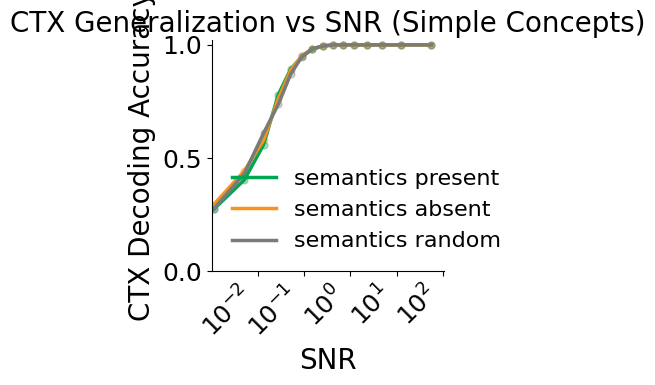

In [11]:
snr_values = np.asarray(shared_snr_levels, dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
finite_noise_levels = np.asarray(shared_noise_levels, dtype=int)[finite_mask]

filtered_results = deepcopy(generalization_simple_complex_results)
filtered_results["noise_levels"] = finite_noise_levels
for network_mode in filtered_results["network_modes"]:
    summary = filtered_results["summary"][network_mode]
    summary["simple_seed_curves"] = summary["simple_seed_curves"][:, finite_mask]
    summary["simple_mean_curve"] = summary["simple_mean_curve"][finite_mask]
    summary["simple_std_curve"] = summary["simple_std_curve"][finite_mask]

fig, ax = plt.subplots(figsize=(3, 3))
plot_generalization_simple_complex_curve(
    filtered_results,
    curve_type="simple",
    ax=ax,
    ylabel="CTX Decoding Accuracy",
    xlabel="SNR",
    x_values=finite_snr_values,
)
ax.set_xscale("log")
ax.set_title("CTX Generalization vs SNR (Simple Concepts)", fontsize=20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
#plt.savefig("Figures_SVG/6b.svg", dpi=300, transparent=True)
#plt.show()



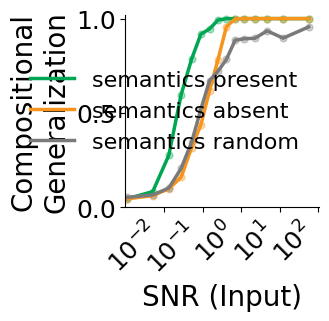

In [12]:
snr_values = np.asarray(shared_snr_levels, dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
finite_noise_levels = np.asarray(shared_noise_levels, dtype=int)[finite_mask]

filtered_results = deepcopy(generalization_simple_complex_results)
filtered_results["noise_levels"] = finite_noise_levels
for network_mode in filtered_results["network_modes"]:
    summary = filtered_results["summary"][network_mode]
    summary["complex_seed_curves"] = summary["complex_seed_curves"][:, finite_mask]
    summary["complex_mean_curve"] = summary["complex_mean_curve"][finite_mask]
    summary["complex_std_curve"] = summary["complex_std_curve"][finite_mask]

fig, ax = plt.subplots(figsize=(2.5, 2.5))
plot_generalization_simple_complex_curve(
    filtered_results,
    curve_type="complex",
    ax=ax,
    ylabel="Compositional\nGeneralization",
    xlabel="SNR (Input)",
    x_values=finite_snr_values,
)
ax.set_xscale("log")
#ax.set_title("Test Generalization vs SNR (Complex Concepts)", fontsize=20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
#legend_ = ax.get_legend()
sns.despine()
plt.savefig("Figures_SVG/6d.svg", dpi=300, transparent=True)
plt.show()



## 6d1 Setup


In [13]:
recording_parameters = {
    "regions": ["mtl_sensory"],
    "rate_activity": 1,
    "connections": [],
    "rate_connectivity": np.inf,
}

input_params = {
    "num_days": 600,
    "day_length": 80,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 4,
}

latent_specs = {
    "num": 2,
    "total_sizes": [50, 50],
    "act_sizes": [10, 10],
    "dims": [5, 5],
    "prob_list": [0.5 / 5 if i == j else 0.5 / 20 for i in range(5) for j in range(5)],
}

num_cpu = 12
job_print_rate = np.inf
num_stored_recordings = 10
verbose_jobs = False

seeds = shared_seeds
noise_levels = shared_noise_levels

net_params = deepcopy(network_parameters)
trained_networks = train_phase_split_networks(
    network_parameters=net_params,
    input_params=input_params,
    latent_specs=latent_specs,
    seed=0,
    pretrain_num_swaps=4,
    duration_phase_A=200,
    duration_phase_B=400,
    total_days=600,
    checkpoint_day=200,
    print_rate=50,
)

trained_networks_for_figures = {
    name: deepcopy(network)
    for name, network in trained_networks.items()
}
trained_networks_for_figures["semantics_clean"] = deepcopy(trained_networks["semantics_present"])

trained_networks_for_figures = fig6b_utils.attach_ctx_replay_readout_orderings_to_dict(
    trained_networks_for_figures,
    input_params=input_params,
    latent_specs=latent_specs,
    num_days=100,
    num_swaps=input_params["num_swaps"],
    include_simple=True,
    include_complex=False,
)

generalization_experiment_params = build_codex_figure_5_experiment_params(
    trained_networks=trained_networks_for_figures,
    recording_parameters=recording_parameters,
    input_params=input_params,
    latent_specs=latent_specs,
    seeds=seeds,
    noise_levels=noise_levels,
    days_per_level=50,
    semantic_load=1,
    num_stored_recordings=num_stored_recordings,
    print_rate=job_print_rate,
    verbose=verbose_jobs,
)

0
50
100
150
0
50
100
150
200
250
300
350
0
50
100
150
200
250
300
350
0
50
100
150
200
250
300
350


## 6d1. MTL-sensory Semantic Clustering, Simple Concepts


In [14]:
with multiprocessing.Pool(processes=num_cpu) as pool:
    generalization_job_results = pool.starmap(
        measure_sleep_a_awake_generalization_job,
        generalization_experiment_params,
    )

generalization_results = aggregate_codex_figure_5_generalization_results(
    generalization_job_results,
    noise_levels=noise_levels,
    seeds=seeds,
)
generalization_results["snr_levels"] = np.array(
    [dict(zip(shared_noise_levels, shared_snr_levels))[int(level)] for level in noise_levels],
    dtype=float,
)



000


000


0
0
0
0
00

0
0
00

0
00

0
0
00
0

00

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/Figure_6B_utils.py:616: RuntimeWarning: Mean of empty slice
  "replay_snr_mean_curve": np.nanmean(replay_snr_seed_curves, axis=0),
/Users/albertalbesagonzalez/Library/Python/3.9/lib/python/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [15]:
if "generalization_results" not in globals():
    raise NameError(
        "generalization_results is not defined. Run the simulation/aggregation cell first."
    )

with open("Data/fig_5_codex_generalization_vs_noise.pickle", "wb") as handle:
    pickle.dump(generalization_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [16]:
with open("Data/fig_5_codex_generalization_vs_noise.pickle", "rb") as handle:
    generalization_results = pickle.load(handle)



([<matplotlib.axis.YTick at 0x3069d03a0>,
 [Text(0, 0.0, '0'), Text(0, 0.7071067811865475, 'Max.')])

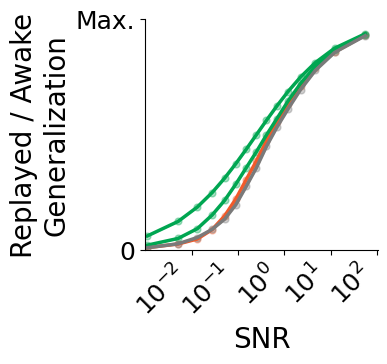

In [17]:

snr_values = np.asarray(generalization_results["snr_levels"], dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
filtered_results = deepcopy(generalization_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
filtered_results["snr_levels"] = finite_snr_values
for network_name in filtered_results["summary"]:
    summary = filtered_results["summary"][network_name]
    summary["seed_curves"] = np.asarray(summary["seed_curves"])[:, finite_mask]
    summary["mean_curve"] = np.asarray(summary["mean_curve"])[finite_mask]
    summary["std_curve"] = np.asarray(summary["std_curve"])[finite_mask]

fig, ax = plt.subplots(figsize=(3, 3))

plot_codex_figure_5(
    filtered_results,
    ax=ax,
    ylabel="Replayed / Awake\nGeneralization",
    xlabel="SNR",
    x_values=finite_snr_values,
    xscale="log",
)

ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig("Figures_SVG/6f.svg", dpi=300, transparent=True)

plt.ylim([0, 1/np.sqrt(2)])
plt.yticks([0,  1/np.sqrt(2)], [0, "Max."])



In [18]:
semantic_load_2_days = 200
semantic_load_2_network = deepcopy(trained_networks["semantics_present"])
semantic_load_2_network.max_semantic_load_replay = 2
semantic_load_2_network.frozen = False
semantic_load_2_network.init_recordings(
    {
        "regions": [],
        "rate_activity": np.inf,
        "connections": [],
        "rate_connectivity": np.inf,
    }
)
semantic_load_2_input_params = fig6b_utils._make_input_params(
    input_params,
    latent_specs,
    num_days=semantic_load_2_days,
    num_swaps=input_params["num_swaps"],
)
_, _, _, semantic_load_2_network = fig6b_utils._run_network_with_progress(
    semantic_load_2_network,
    semantic_load_2_input_params,
    sleep=True,
    print_rate=25,
    verbose=True,
    job_label="semantic-charge-2-pretrain",
)

trained_networks_for_figures_load_2 = {
    "semantics_absent": deepcopy(semantic_load_2_network),
    "semantics_random": deepcopy(semantic_load_2_network),
    "semantics_present": deepcopy(semantic_load_2_network),
    "semantics_clean": deepcopy(semantic_load_2_network),
}
trained_networks_for_figures_load_2["semantics_absent"].sensory_replay_only = True
trained_networks_for_figures_load_2["semantics_random"].lesioned = {"mtl_semantic"}

trained_networks_for_figures_load_2 = fig6b_utils.attach_ctx_replay_readout_orderings_to_dict(
    trained_networks_for_figures_load_2,
    input_params=input_params,
    latent_specs=latent_specs,
    num_days=100,
    num_swaps=input_params["num_swaps"],
    include_simple=True,
    include_complex=True,
)

load_2_generalization_experiment_params = build_codex_figure_5_experiment_params(
    trained_networks=trained_networks_for_figures_load_2,
    recording_parameters=recording_parameters,
    input_params=input_params,
    latent_specs=latent_specs,
    seeds=seeds,
    noise_levels=noise_levels,
    days_per_level=50,
    semantic_load=2,
    num_stored_recordings=num_stored_recordings,
    print_rate=job_print_rate,
    verbose=verbose_jobs,
)



[pid=44712] semantic-charge-2-pretrain generated input shape=(200, 80, 100) sleep=True
[pid=44712] semantic-charge-2-pretrain day=1/200 stage=awake:start
[pid=44712] semantic-charge-2-pretrain day=1/200 stage=awake:end
[pid=44712] semantic-charge-2-pretrain day=1/200 stage=sleep:start
[pid=44712] semantic-charge-2-pretrain day=1/200 stage=sleep:end
[pid=44712] semantic-charge-2-pretrain day=26/200 stage=awake:start
[pid=44712] semantic-charge-2-pretrain day=26/200 stage=awake:end
[pid=44712] semantic-charge-2-pretrain day=26/200 stage=sleep:start
[pid=44712] semantic-charge-2-pretrain day=26/200 stage=sleep:end
[pid=44712] semantic-charge-2-pretrain day=51/200 stage=awake:start
[pid=44712] semantic-charge-2-pretrain day=51/200 stage=awake:end
[pid=44712] semantic-charge-2-pretrain day=51/200 stage=sleep:start
[pid=44712] semantic-charge-2-pretrain day=51/200 stage=sleep:end
[pid=44712] semantic-charge-2-pretrain day=76/200 stage=awake:start
[pid=44712] semantic-charge-2-pretrain day=76

In [19]:
with multiprocessing.Pool(processes=num_cpu) as pool:
    load_2_generalization_job_results = pool.starmap(
        measure_sleep_a_awake_generalization_job,
        load_2_generalization_experiment_params,
    )

load_2_generalization_results = aggregate_codex_figure_5_generalization_results(
    load_2_generalization_job_results,
    noise_levels=noise_levels,
    seeds=seeds,
)
load_2_generalization_results["snr_levels"] = np.array(
    [dict(zip(shared_noise_levels, shared_snr_levels))[int(level)] for level in noise_levels],
    dtype=float,
)



0000

0

0
0

0000
0





/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())
/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())
/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTe

00

0
0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())
/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())
/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTe

0
00
0

0
0
00

00

0
0
0
0
000


0
0
00

0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Library/Python/3.9/lib/python/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


In [20]:
if "load_2_generalization_results" not in globals():
    raise NameError(
        "load_2_generalization_results is not defined. Run the simulation/aggregation cell first."
    )

with open("Data/fig_5_codex_generalization_vs_noise_load_2.pickle", "wb") as handle:
    pickle.dump(load_2_generalization_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [21]:
with open("Data/fig_5_codex_generalization_vs_noise_load_2.pickle", "rb") as handle:
    load_2_generalization_results = pickle.load(handle)



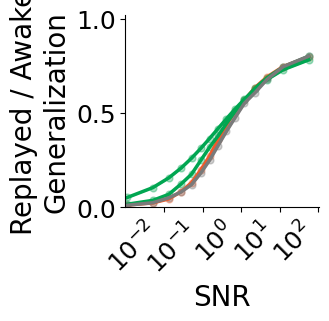

In [22]:
snr_values = np.asarray(load_2_generalization_results["snr_levels"], dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
filtered_results = deepcopy(load_2_generalization_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
filtered_results["snr_levels"] = finite_snr_values
for network_name in filtered_results["summary"]:
    summary = filtered_results["summary"][network_name]
    summary["seed_curves"] = np.asarray(summary["seed_curves"])[:, finite_mask]
    summary["mean_curve"] = np.asarray(summary["mean_curve"])[finite_mask]
    summary["std_curve"] = np.asarray(summary["std_curve"])[finite_mask]
    if "replay_snr_seed_curves" in summary:
        summary["replay_snr_seed_curves"] = np.asarray(summary["replay_snr_seed_curves"])[:, finite_mask]
        summary["replay_snr_mean_curve"] = np.asarray(summary["replay_snr_mean_curve"])[finite_mask]
        summary["replay_snr_std_curve"] = np.asarray(summary["replay_snr_std_curve"])[finite_mask]

fig, ax = plt.subplots(figsize=(2.5, 2.5))
plot_codex_figure_5(
    filtered_results,
    ax=ax,
    ylabel="Replayed / Awake\nGeneralization",
    xlabel="SNR",
    x_values=finite_snr_values,
    xscale="log",
)

ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig(
    "Figures_SVG/6f.svg",
    dpi=300,
    transparent=True,
)

#plt.ylim([0, 1/np.sqrt(2)])
#plt.yticks([0,  1/np.sqrt(2)], [0, "Max."])
plt.show()




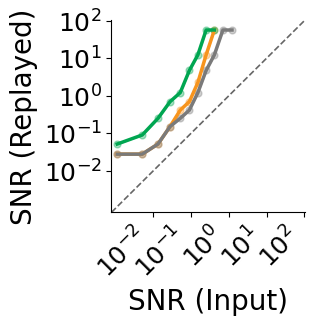

In [23]:
snr_values = np.asarray(load_2_generalization_results["snr_levels"], dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
snr_ticklabels = [f"{v:.2f}" for v in finite_snr_values]

network_colors = {
    "semantics_absent": orange,
    "semantics_random": gray,
    "semantics_present": green,
    "semantics_clean": "#00A651",
}
network_labels = {
    "semantics_absent": "semantics absent",
    "semantics_random": "semantics random",
    "semantics_present": "semantics present",
    "semantics_clean": "semantics clean",
}

fig, ax = plt.subplots(figsize=(2.5, 2.5))

for network_name in load_2_generalization_results["summary"]:
    summary = load_2_generalization_results["summary"][network_name]
    seed_curves = np.asarray(summary["replay_snr_seed_curves"], dtype=float)[:, finite_mask]
    mean_curve = np.asarray(summary["replay_snr_mean_curve"], dtype=float)[finite_mask]
    std_curve = np.asarray(summary["replay_snr_std_curve"], dtype=float)[finite_mask]
    color = network_colors.get(network_name, "#000000")
    label = network_labels.get(network_name, network_name)

    for seed_curve in seed_curves:
        ax.scatter(finite_snr_values, seed_curve, color=color, alpha=0.35, s=24)

    ax.plot(finite_snr_values, mean_curve, color=color, linewidth=2.5, label=label)
    ax.fill_between(
        finite_snr_values,
        mean_curve - std_curve,
        mean_curve + std_curve,
        color=color,
        alpha=0.15,
    )


ax.set_xlabel("SNR (Input)", fontsize=20)
ax.set_ylabel("SNR (Replayed)", fontsize=20)

ax.set_xscale("log")
ax.set_yscale("log")

x_limits = ax.get_xlim()
y_limits = ax.get_ylim()
shared_decade_candidates = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
shared_lower = min(x_limits[0], y_limits[0], 1e-3)
shared_upper = max(x_limits[1], y_limits[1], 1e2)
shared_ticks = shared_decade_candidates[(shared_decade_candidates >= shared_lower) & (shared_decade_candidates <= shared_upper)]
identity_x = np.array([shared_lower, shared_upper], dtype=float)
ax.plot(
    identity_x,
    identity_x,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.6,
    zorder=0,
)
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.xaxis.set_major_locator(mticker.FixedLocator(shared_ticks))
ax.yaxis.set_major_locator(mticker.FixedLocator(shared_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.yaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_xlim(shared_lower, shared_upper * 1.05)
ax.set_ylim(shared_lower, shared_upper * 1.05)
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(frameon=False, fontsize=16)
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()

plt.savefig("Figures_SVG/6e.svg", dpi=300, transparent=True)

## 6e1. Cortical Semantic Clustering, Simple Concepts


In [24]:
simple_replay_clustering_networks = {
    name: deepcopy(network)
    for name, network in trained_networks_for_figures.items()
    if name != "semantics_clean"
}

simple_replay_clustering_experiment_params = build_codex_figure_5_experiment_params(
    trained_networks=simple_replay_clustering_networks,
    recording_parameters=recording_parameters,
    input_params=input_params,
    latent_specs=latent_specs,
    seeds=seeds,
    noise_levels=noise_levels,
    days_per_level=50,
    semantic_load=1,
    num_stored_recordings=num_stored_recordings,
    print_rate=job_print_rate,
    verbose=verbose_jobs,
)


In [25]:
with multiprocessing.Pool(processes=num_cpu) as pool:
    simple_replay_clustering_job_results = pool.starmap(
        measure_sleep_a_replay_episode_clustering_job,
        simple_replay_clustering_experiment_params,
    )

simple_replay_clustering_results = aggregate_codex_figure_5_generalization_results(
    simple_replay_clustering_job_results,
    noise_levels=noise_levels,
    seeds=seeds,
)
simple_replay_clustering_results["snr_levels"] = np.array(
    [dict(zip(shared_noise_levels, shared_snr_levels))[int(level)] for level in noise_levels],
    dtype=float,
)


000


00
0
0

00
0
00


0
000
0


00

0
0
00

0
0
00

0
0
0
0
0
0
0
00

0
0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/Figure_6B_utils.py:616: RuntimeWarning: Mean of empty slice
  "replay_snr_mean_curve": np.nanmean(replay_snr_seed_curves, axis=0),
/Users/albertalbesagonzalez/Library/Python/3.9/lib/python/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [26]:
if "simple_replay_clustering_results" not in globals():
    raise NameError(
        "simple_replay_clustering_results is not defined. Run the simulation/aggregation cell first."
    )

with open("Data/fig_5_codex_replay_clustering_vs_noise_simple.pickle", "wb") as handle:
    pickle.dump(simple_replay_clustering_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [27]:
with open("Data/fig_5_codex_replay_clustering_vs_noise_simple.pickle", "rb") as handle:
    simple_replay_clustering_results = pickle.load(handle)



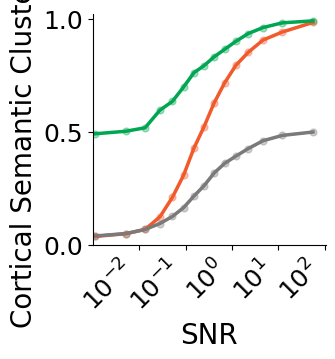

In [28]:
snr_values = np.asarray(simple_replay_clustering_results["snr_levels"], dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
filtered_results = deepcopy(simple_replay_clustering_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
filtered_results["snr_levels"] = finite_snr_values
for network_name in filtered_results["summary"]:
    summary = filtered_results["summary"][network_name]
    summary["seed_curves"] = np.asarray(summary["seed_curves"])[:, finite_mask]
    summary["mean_curve"] = np.asarray(summary["mean_curve"])[finite_mask]
    summary["std_curve"] = np.asarray(summary["std_curve"])[finite_mask]

fig, ax = plt.subplots(figsize=(3, 3))
plot_codex_figure_5(
    filtered_results,
    ax=ax,
    ylabel="Cortical Semantic Clustering",
    xlabel="SNR",
    x_values=finite_snr_values,
    xscale="log",
)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig("Figures_SVG/6e1.svg", dpi=300, transparent=True)
plt.show()




## 6e2. Cortical Semantic Clustering, Complex Concepts


In [29]:
# Replay episode clustering uses full MTL replay states, so we exclude the
# idealized clean condition that does not generate a full MTL replay.
load_2_replay_clustering_networks = {
    name: deepcopy(network)
    for name, network in trained_networks_for_figures_load_2.items()
    if name != "semantics_clean"
}

load_2_replay_clustering_experiment_params = build_codex_figure_5_experiment_params(
    trained_networks=load_2_replay_clustering_networks,
    recording_parameters=recording_parameters,
    input_params=input_params,
    latent_specs=latent_specs,
    seeds=seeds,
    noise_levels=noise_levels,
    days_per_level=50,
    semantic_load=2,
    num_stored_recordings=num_stored_recordings,
    print_rate=job_print_rate,
    verbose=verbose_jobs,
)


In [30]:
with multiprocessing.Pool(processes=num_cpu) as pool:
    load_2_replay_clustering_job_results = pool.starmap(
        measure_sleep_a_replay_episode_clustering_job,
        load_2_replay_clustering_experiment_params,
    )

load_2_replay_clustering_results = aggregate_codex_figure_5_generalization_results(
    load_2_replay_clustering_job_results,
    noise_levels=noise_levels,
    seeds=seeds,
)
load_2_replay_clustering_results["snr_levels"] = np.array(
    [dict(zip(shared_noise_levels, shared_snr_levels))[int(level)] for level in noise_levels],
    dtype=float,
)


00

0
00
0

00

0
0
0
0
0
0
0
00

00

00

00

0
00

0
00

0
0
0
0
0
0
0
0
00

0
0
0
0
0
0


In [ ]:
if "load_2_replay_clustering_results" not in globals():
    raise NameError(
        "load_2_replay_clustering_results is not defined. Run the simulation/aggregation cell first."
    )

with open("Data/fig_5_codex_replay_episode_clustering_vs_noise_load_2.pickle", "wb") as handle:
    pickle.dump(load_2_replay_clustering_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [32]:
with open("Data/fig_5_codex_replay_episode_clustering_vs_noise_load_2.pickle", "rb") as handle:
    load_2_replay_clustering_results = pickle.load(handle)



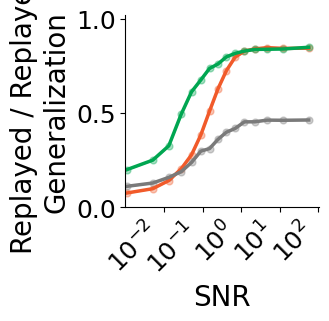

In [33]:
snr_values = np.asarray(load_2_replay_clustering_results["snr_levels"], dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
filtered_results = deepcopy(load_2_replay_clustering_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
filtered_results["snr_levels"] = finite_snr_values
for network_name in filtered_results["summary"]:
    summary = filtered_results["summary"][network_name]
    summary["seed_curves"] = np.asarray(summary["seed_curves"])[:, finite_mask]
    summary["mean_curve"] = np.asarray(summary["mean_curve"])[finite_mask]
    summary["std_curve"] = np.asarray(summary["std_curve"])[finite_mask]

fig, ax = plt.subplots(figsize=(2.5, 2.5))
plot_codex_figure_5(
    filtered_results,
    ax=ax,
    ylabel="Replayed / Replayed\nGeneralization",
    xlabel="SNR",
    x_values=finite_snr_values,
    xscale="log",
)

ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig(
    "Figures_SVG/6g.svg",
    dpi=300,
    transparent=True,
)
plt.show()




## 6f. Replay–CTX Relationships


In [34]:
gray = "#C0C0C0"
purple = "#B05AA3"

In [36]:
# Relate charge-2 replay metrics to downstream CTX episode selectivity.
# We align points by (network_name, num_swaps), averaging across any available seeds.

if "load_2_generalization_results" not in globals():
    with open("Data/fig_5_codex_generalization_vs_noise_load_2.pickle", "rb") as handle:
        load_2_generalization_results = pickle.load(handle)

if "load_2_replay_clustering_results" not in globals():
    with open("Data/fig_5_codex_replay_episode_clustering_vs_noise_load_2.pickle", "rb") as handle:
        load_2_replay_clustering_results = pickle.load(handle)

if "load_2_learning_noise_results" not in globals():
    with open("Data/fig_5_codex_ctx_episode_selectivity_vs_learning_noise_charge_2.pickle", "rb") as handle:
        load_2_learning_noise_results = pickle.load(handle)

common_networks = ["semantics_absent", "semantics_random", "semantics_present"]

def mean_by_network_and_noise(raw_results, value_key):
    grouped = {}
    for job in raw_results:
        network_name = job.get("network_name", job.get("network_mode"))
        if network_name not in common_networks:
            continue
        key = (network_name, int(job["num_swaps"]))
        grouped.setdefault(key, []).append(float(job[value_key]))
    return {
        key: float(np.mean(values))
        for key, values in grouped.items()
    }

generalization_by_key = mean_by_network_and_noise(
    load_2_generalization_results["raw_results"],
    "mean_margin",
)
replay_clustering_by_key = mean_by_network_and_noise(
    load_2_replay_clustering_results["raw_results"],
    "mean_margin",
)
ctx_episode_selectivity_by_key = mean_by_network_and_noise(
    load_2_learning_noise_results["raw_results"],
    "ctx_episode_selectivity",
)

shared_keys_generalization = sorted(
    set(generalization_by_key.keys()) & set(ctx_episode_selectivity_by_key.keys())
)
shared_keys_clustering = sorted(
    set(replay_clustering_by_key.keys()) & set(ctx_episode_selectivity_by_key.keys())
)

x_load_2_generalization = np.array(
    [generalization_by_key[key] for key in shared_keys_generalization],
    dtype=float,
)
y_load_2_generalization_ctx = np.array(
    [ctx_episode_selectivity_by_key[key] for key in shared_keys_generalization],
    dtype=float,
)

x_load_2_replay_clustering = np.array(
    [replay_clustering_by_key[key] for key in shared_keys_clustering],
    dtype=float,
)
y_load_2_replay_clustering_ctx = np.array(
    [ctx_episode_selectivity_by_key[key] for key in shared_keys_clustering],
    dtype=float,
)

if len(x_load_2_generalization) == 0 or len(x_load_2_replay_clustering) == 0:
    raise ValueError(
        "No overlapping charge-2 points were found between the result sets after matching by underlying corruption level. "
        "Rerun the upstream charge-2 simulations if these files should match."
    )

generalization_r = np.corrcoef(x_load_2_generalization, y_load_2_generalization_ctx)[0, 1]
clustering_r = np.corrcoef(x_load_2_replay_clustering, y_load_2_replay_clustering_ctx)[0, 1]
generalization_coef = np.polyfit(x_load_2_generalization, y_load_2_generalization_ctx, deg=1)
clustering_coef = np.polyfit(x_load_2_replay_clustering, y_load_2_replay_clustering_ctx, deg=1)
generalization_pred = np.polyval(generalization_coef, x_load_2_generalization)
clustering_pred = np.polyval(clustering_coef, x_load_2_replay_clustering)
generalization_ss_res = np.sum((y_load_2_generalization_ctx - generalization_pred) ** 2)
generalization_ss_tot = np.sum((y_load_2_generalization_ctx - y_load_2_generalization_ctx.mean()) ** 2)
clustering_ss_res = np.sum((y_load_2_replay_clustering_ctx - clustering_pred) ** 2)
clustering_ss_tot = np.sum((y_load_2_replay_clustering_ctx - y_load_2_replay_clustering_ctx.mean()) ** 2)
generalization_r2 = 1 - generalization_ss_res / generalization_ss_tot
clustering_r2 = 1 - clustering_ss_res / clustering_ss_tot

print(f"Generalization vs CTX points: {len(shared_keys_generalization)}")
print(f"Replay clustering vs CTX points: {len(shared_keys_clustering)}")
print("Generalization/CTX Pearson r:", generalization_r)
print("Generalization/CTX R^2:", generalization_r2)
print("Replay clustering/CTX Pearson r:", clustering_r)
print("Replay clustering/CTX R^2:", clustering_r2)



Generalization vs CTX points: 45
Replay clustering vs CTX points: 45
Generalization/CTX Pearson r: 0.8670062957117339
Generalization/CTX R^2: 0.7516999168037825
Replay clustering/CTX Pearson r: 0.9527379925742668
Replay clustering/CTX R^2: 0.9077096824944442


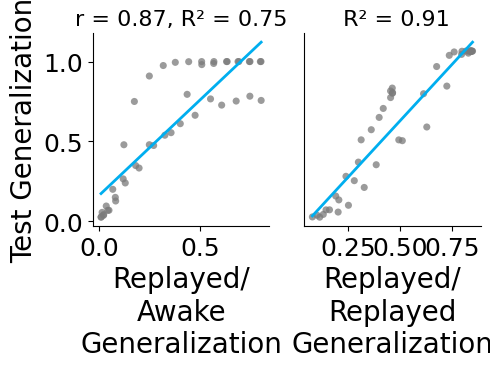

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

scatter_kws = dict(s=26, alpha=0.75, color="#7A7A7A", edgecolors="none")
trend_color = "#00AEEF"

# Plot 1: replay generalization margin vs CTX episode selectivity
axes[0].scatter(
    x_load_2_generalization,
    y_load_2_generalization_ctx,
    **scatter_kws,
)
coef_generalization = np.polyfit(x_load_2_generalization, y_load_2_generalization_ctx, deg=1)
xx_generalization = np.linspace(x_load_2_generalization.min(), x_load_2_generalization.max(), 200)
axes[0].plot(
    xx_generalization,
    np.polyval(coef_generalization, xx_generalization),
    color=trend_color,
    linewidth=2,
)
axes[0].set_xlabel("Replayed/\nAwake\nGeneralization", fontsize=20)
axes[0].set_ylabel("Test Generalization", fontsize=20)
axes[0].set_title(f"r = {generalization_r:.2f}, R² = {generalization_r2:.2f}", fontsize=16)
axes[0].tick_params(labelsize=18)

# Plot 2: replay episode-cluster margin vs CTX episode selectivity
axes[1].scatter(
    x_load_2_replay_clustering,
    y_load_2_replay_clustering_ctx,
    **scatter_kws,
)
coef_clustering = np.polyfit(x_load_2_replay_clustering, y_load_2_replay_clustering_ctx, deg=1)
xx_clustering = np.linspace(x_load_2_replay_clustering.min(), x_load_2_replay_clustering.max(), 200)
axes[1].plot(
    xx_clustering,
    np.polyval(coef_clustering, xx_clustering),
    color=trend_color,
    linewidth=2,
)
axes[1].set_xlabel("Replayed/\nReplayed\nGeneralization", fontsize=20)
axes[1].set_yticks([])
axes[1].tick_params(labelsize=18)
axes[1].tick_params(labelsize=18)
axes[1].set_title(f" R² = {clustering_r2:.2f}", fontsize=16)

for ax in axes:
    sns.despine(ax=ax)


plt.savefig(
    "Figures_SVG/S5a.svg",
    dpi=300,
    transparent=True,
)
plt.show()
